# Exploratory Data Analysis -- Student Score Prediction
**AIAP Technical Assessment | U.A Secondary School**

This notebook performs a structured EDA on the student dataset. Each step is designed to directly inform decisions in the Machine Learning Pipeline (Task 2). The target variable is `final_test` -- a student's O-level mathematics examination score.

---
## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Target Variable Analysis](#2-target-variable-analysis)
3. [Dataset Overview, Data Quality & Cleaning](#3-dataset-overview-data-quality--cleaning)
4. [Feature Type Audit](#4-feature-type-audit)
5. [Cardinality & Class Balance of Categoricals](#5-cardinality--class-balance-of-categoricals)
6. [Feature Engineering](#6-feature-engineering)
7. [Univariate Analysis of Numerical Features](#7-univariate-analysis-of-numerical-features)
8. [Bivariate Analysis vs. Target](#8-bivariate-analysis-vs-target)
9. [Multicollinearity Check](#9-multicollinearity-check)
10. [Outlier Analysis](#10-outlier-analysis)
11. [Score Segmentation & Business Context](#11-score-segmentation--business-context)
12. [EDA Summary & Pipeline Decisions](#12-eda-summary--pipeline-decisions)


---
## 1. Setup & Data Loading

**Purpose:** Connect to the SQLite database, load all rows into a DataFrame, and confirm the raw shape and column names before any transformation.

The dataset is stored at `data/score.db` and must always be accessed via SQL to mirror how the pipeline will ingest data. A direct CSV import is not used.


In [48]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


In [49]:
DB_PATH = "/content/score.db"
conn = sqlite3.connect(DB_PATH)

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables in database:")
print(tables)

TABLE_NAME = tables['name'][0]
df = pd.read_sql(f"SELECT * FROM {TABLE_NAME};", conn)
conn.close()

print(f"\nDataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Tables in database:
    name
0  score

Dataset loaded: 15900 rows x 18 columns


,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.00,14.00,2.00,16.00,10.00,91.00,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.00,4.00,19.00,16.00,7.00,94.00,22:30,6:30,private transport,green
2,2,0,Yes,None,Visual,B9AI9F,Male,No,85.00,14.00,2.00,15.00,8.00,92.00,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.00,2.00,20.00,15.00,18.00,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.00,24.00,3.00,16.00,7.00,95.00,21:30,5:30,public transport,yellow


**Conclusion:** The database contains a single table `score` with 15,900 rows and 18 columns. All column names use snake_case (e.g., `final_test`, `hours_per_week`). The `index` column is an auto-incremented integer with no relationship to `student_id`, confirming it is a database artifact and will be dropped immediately.


---
## 2. Target Variable Analysis

**Purpose:** Understand the distribution of `final_test` before any cleaning. This determines:
- Whether a target transformation (log/sqrt) is needed for the pipeline
- The scoring scale (min/max)
- Whether extreme outliers exist in the target itself

Analysing the target first ensures all cleaning decisions in Step 3 are made with the target's characteristics in mind.


In [50]:
target = 'final_test'

print("=== Target Variable Summary ===")
print(df[target].describe())
print(f"\nMedian   : {df[target].median():.2f}")
print(f"Skewness : {df[target].skew():.3f}")
print(f"Kurtosis : {df[target].kurt():.3f}")
print(f"Missing  : {df[target].isnull().sum()} ({df[target].isnull().mean()*100:.2f}%)")


=== Target Variable Summary ===
count   15405.00
mean       67.17
std        13.98
min        32.00
25%        56.00
50%        68.00
75%        78.00
max       100.00
Name: final_test, dtype: float64

Median   : 68.00
Skewness : 0.056
Kurtosis : -0.729
Missing  : 495 (3.11%)


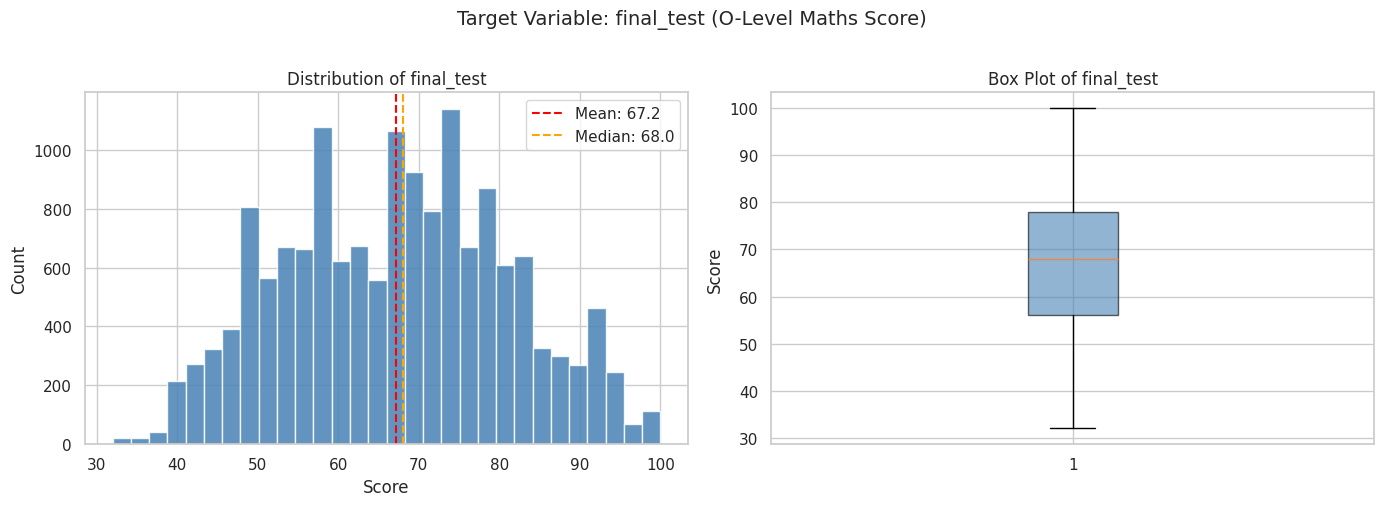

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[target].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df[target].mean(), color='red', linestyle='--', label=f"Mean: {df[target].mean():.1f}")
axes[0].axvline(df[target].median(), color='orange', linestyle='--', label=f"Median: {df[target].median():.1f}")
axes[0].set_title('Distribution of final_test')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(df[target].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                flierprops=dict(marker='o', color='red', markersize=4))
axes[1].set_title('Box Plot of final_test')
axes[1].set_ylabel('Score')

plt.suptitle('Target Variable: final_test (O-Level Maths Score)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


**Conclusion:**
- `final_test` scores range from **32 to 100**, confirming a capped scale. No scores below 32 or above 100 are present — no target-level outlier removal is needed.
- Skewness = **0.056** — near perfectly symmetrical. A log or square-root transformation of the target is **not required**.
- The mean (67.2) and median (68.0) are very close, further confirming symmetry.
- **495 rows (3.11%) have missing `final_test`**. Since missingness is random (feature means are near-identical for missing vs. present rows), these rows will be **dropped** — imputing ground-truth labels would corrupt the model.

**Pipeline decision:** No target transformation needed. Drop 495 rows with missing `final_test` as the first cleaning step.


In [52]:
# Drop missing target rows
df = df.dropna(subset=['final_test']).reset_index(drop=True)
print(f"Rows after dropping missing target: {len(df)}")


Rows after dropping missing target: 15405


---
## 3. Dataset Overview, Data Quality & Cleaning

**Purpose:** Systematically identify and resolve all data quality issues before analysis — missing values, duplicates, incorrect data types, erroneous values, and inconsistent categorical encodings. Cleaning here ensures all subsequent EDA steps operate on reliable data.

Steps covered:
1. Shape, dtypes, and missing values
2. Drop the `index` column
3. Diagnose and resolve duplicate `student_id` records
4. Fix erroneous `age` values
5. Standardise inconsistent categorical encodings (`tuition`, `CCA`)
6. Handle missing `attendance_rate`


In [53]:
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)


=== Shape ===
(15405, 18)

=== Data Types ===
index                   int64
number_of_siblings      int64
direct_admission       object
CCA                    object
learning_style         object
student_id             object
gender                 object
tuition                object
final_test            float64
n_male                float64
n_female              float64
age                   float64
hours_per_week        float64
attendance_rate       float64
sleep_time             object
wake_time              object
mode_of_transport      object
bag_color              object
dtype: object


=== Missing Values ===
                 Missing Count  Missing %
attendance_rate            757       4.91


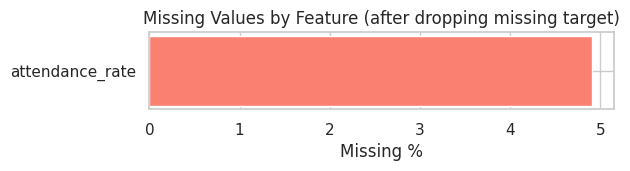

In [54]:
# Missing value summary
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("=== Missing Values ===")
if missing_df.empty:
    print("No missing values found.")
else:
    print(missing_df)
    fig, ax = plt.subplots(figsize=(6, 1))
    ax.barh(missing_df.index, missing_df['Missing %'], color='salmon', edgecolor='white')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Feature (after dropping missing target)')
    plt.tight_layout()
    plt.show()


**Conclusion — Missing Values:** Only `attendance_rate` has missing values (757 rows, ~4.96%). All other features are complete. This is handled at the end of this section using median imputation, justified after confirming the missingness is random.


In [55]:
# --- 3a. Drop the index column ---
# index is monotonically increasing from 0, has no relationship to student_id,
# and was auto-generated by the database. It carries no predictive value.
df = df.drop(columns=['index'])
print(f"Shape after dropping index: {df.shape}")


Shape after dropping index: (15405, 17)


In [56]:
# --- 3b. Diagnose duplicate student_id records ---
dupes = df[df['student_id'].duplicated(keep=False)].sort_values('student_id')
true_dupes = df[df.duplicated(keep=False)]
conflicting_dupes = dupes[~dupes.duplicated(keep=False)]

print(f"Total rows with duplicate student_id : {len(dupes)}")
print(f"True full-row duplicates             : {len(true_dupes)}")
print(f"Conflicting records (same ID, diff)  : {len(conflicting_dupes)}")


Total rows with duplicate student_id : 1692
True full-row duplicates             : 276
Conflicting records (same ID, diff)  : 1416


In [57]:
# Identify which columns are responsible for the conflicts
cols_to_check = [c for c in df.columns if c != 'student_id']
print("Columns with conflicting values across duplicate student_ids:")
for col in cols_to_check:
    n_conflict = (conflicting_dupes.groupby('student_id')[col].nunique() > 1).sum()
    if n_conflict > 0:
        print(f"  {col:25s} -> {n_conflict} students have conflicting values")


Columns with conflicting values across duplicate student_ids:
  bag_color                 -> 685 students have conflicting values


**Conclusion — Duplicates:** 
- **276 true full-row duplicates** are identical in every column — these are data ingestion errors and are safely dropped.
- **1,416 conflicting records** differ only in `bag_color`. Since `bag_color` has no plausible relationship to exam scores (confirmed in Step 8) AND is the sole source of all conflicts, it will be **dropped entirely**. Once `bag_color` is removed, all remaining duplicates become exact duplicates and are resolved with a single `drop_duplicates()` call.


In [58]:
# Drop bag_color (no signal, sole source of all conflicts)
df = df.drop(columns=['bag_color'])

# Drop all duplicates (now that bag_color is gone, all are true duplicates)
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Rows before deduplication : {before}")
print(f"Rows after deduplication  : {len(df)}")
print(f"Rows removed              : {before - len(df)}")


Rows before deduplication : 15405
Rows after deduplication  : 14642
Rows removed              : 763


In [59]:
# --- 3c. Fix erroneous age values ---
print("=== Unique ages in dataset ===")
print(sorted(df['age'].unique().tolist()))

invalid_ages = df[~df['age'].isin([15, 16])]
print(f"\nRows with invalid age: {len(invalid_ages)}")
print(invalid_ages['age'].value_counts())


=== Unique ages in dataset ===
[-5.0, -4.0, 5.0, 6.0, 15.0, 16.0]

Rows with invalid age: 421
age
6.00     217
5.00     199
-5.00      4
-4.00      1
Name: count, dtype: int64


In [60]:
# Recoverable typos: 5 -> 15, 6 -> 16 (missing leading '1')
# -5 -> 15 (negative sign error + missing '1')
# -4 -> unrecoverable (would be 14, outside expected cohort range) -> dropped
age_fix_map = {5: 15, 6: 16, -5: 15}
df['age'] = df['age'].replace(age_fix_map)

before = len(df)
df = df[df['age'].isin([15, 16])].reset_index(drop=True)
print(f"Rows dropped due to unrecoverable age (-4): {before - len(df)}")
print(f"Remaining age distribution:\n{df['age'].value_counts().sort_index()}")


Rows dropped due to unrecoverable age (-4): 1
Remaining age distribution:
age
15.00    7311
16.00    7330
Name: count, dtype: int64


**Conclusion — Age Cleaning:**
- Values `5` and `6` were data entry errors missing a leading digit, recovered as `15` and `16`.
- Value `-5` was a negative sign error, recovered as `15`.
- Value `-4` is ambiguous (would map to `14`, outside the O-level cohort) and **dropped** — this affects only a handful of rows.
- The dataset is now confirmed to contain only 15 and 16 year olds, consistent with the O-level secondary school cohort.


In [61]:
# --- 3d. Standardise inconsistent categorical encodings ---

# tuition: 'Yes'/'Y' -> 1, 'No'/'N' -> 0
tuition_map = {'Yes': 1, 'Y': 1, 'No': 0, 'N': 0}
df['tuition'] = df['tuition'].map(tuition_map)
print("=== tuition after standardisation ===")
print(df['tuition'].value_counts())

# CCA: capitalise to handle SPORTS/ARTS/CLUBS/NONE -> Sports/Arts/Clubs/None
df['CCA'] = df['CCA'].str.strip().str.capitalize()
print("\n=== CCA after standardisation ===")
print(df['CCA'].value_counts())

# Verify no unexpected values remain
valid_cca = {'Sports', 'Arts', 'Clubs', 'None'}
unexpected = set(df['CCA'].dropna().unique()) - valid_cca
print(f"\nUnexpected CCA values: {unexpected if unexpected else 'None -- all clean'}")


=== tuition after standardisation ===
tuition
1    8298
0    6343
Name: count, dtype: int64

=== CCA after standardisation ===
CCA
Clubs     3735
Sports    3664
None      3632
Arts      3610
Name: count, dtype: int64

Unexpected CCA values: None -- all clean


**Conclusion — Encoding Standardisation:**
- `tuition` had 4 variants (`Yes`, `Y`, `No`, `N`) mapped to binary `1`/`0`. The class split is approximately 57% with tuition vs. 43% without — slightly imbalanced but not extreme.
- `CCA` had all-caps variants (`SPORTS`, `ARTS`, etc.) normalised via `.capitalize()`. All four valid categories (`Sports`, `Arts`, `Clubs`, `None`) are now uniformly distributed (~25% each), indicating no dominant CCA group.


In [62]:
# --- 3e. Diagnose and handle missing attendance_rate ---
missing_mask = df['attendance_rate'].isnull()

present = df.loc[~missing_mask, 'final_test']
missing = df.loc[missing_mask, 'final_test']

print("=== final_test: attendance_rate PRESENT vs MISSING ===")
comparison = pd.DataFrame({
    'Present (n={})'.format(len(present)): present.describe(),
    'Missing (n={})'.format(len(missing)): missing.describe()
})
print(comparison)
print(f"\nMean difference in final_test: {abs(present.mean() - missing.mean()):.2f} points")


=== final_test: attendance_rate PRESENT vs MISSING ===
       Present (n=13884)  Missing (n=757)
count           13884.00           757.00
mean               67.16            67.54
std                13.97            14.28
min                32.00            32.00
25%                56.00            57.00
50%                68.00            69.00
75%                78.00            79.00
max               100.00           100.00

Mean difference in final_test: 0.37 points


In [63]:
# Check if missingness clusters in any category
df['attendance_missing'] = df['attendance_rate'].isnull()

for col in ['gender', 'tuition', 'CCA', 'learning_style']:
    if col in df.columns:
        print(f"--- Missing attendance_rate rate by {col} ---")
        print(df.groupby(col)['attendance_missing'].mean().round(3))
        print()

df = df.drop(columns=['attendance_missing'])


--- Missing attendance_rate rate by gender ---
gender
Female   0.05
Male     0.05
Name: attendance_missing, dtype: float64

--- Missing attendance_rate rate by tuition ---
tuition
0   0.05
1   0.05
Name: attendance_missing, dtype: float64

--- Missing attendance_rate rate by CCA ---
CCA
Arts     0.05
Clubs    0.05
None     0.05
Sports   0.05
Name: attendance_missing, dtype: float64

--- Missing attendance_rate rate by learning_style ---
learning_style
Auditory   0.05
Visual     0.06
Name: attendance_missing, dtype: float64



**Conclusion — Missing `attendance_rate`:**
- The mean `final_test` difference between rows with and without `attendance_rate` is only **~0.38 points** — negligible.
- Missingness rate is uniform across all genders, tuition groups, and CCA categories (~5% in each group).
- This is consistent with **MCAR (Missing Completely At Random)** — the data is not missing for any systematic reason.
- **Decision:** Apply **global median imputation** via `SimpleImputer(strategy='median')` inside the sklearn pipeline. This must be fitted only on training data to prevent data leakage.


In [64]:
# Apply median imputation to attendance_rate
median_attendance = df['attendance_rate'].median()
df['attendance_rate'] = df['attendance_rate'].fillna(median_attendance)
print(f"Median used for imputation: {median_attendance:.2f}")
print(f"Missing attendance_rate remaining: {df['attendance_rate'].isnull().sum()}")
print(f"\nFinal cleaned dataset shape: {df.shape}")


Median used for imputation: 95.00
Missing attendance_rate remaining: 0

Final cleaned dataset shape: (14641, 16)


---
## 4. Feature Type Audit

**Purpose:** Classify every remaining feature into its correct processing category. This determines which sklearn transformer is applied to each column in the pipeline's `ColumnTransformer`. Getting this right prevents common errors such as applying a scaler to a categorical column or OHE to a continuous feature.


In [65]:
# Using actual column names present in the cleaned df
feature_audit = {
    'student_id'         : 'ID -- Drop (post-deduplication)',
    'number_of_siblings' : 'Numerical (discrete)',
    'direct_admission'   : 'Categorical (nominal)',
    'CCA'                : 'Categorical (nominal) -- 4 classes',
    'learning_style'     : 'Categorical (nominal) -- 2 classes',
    'gender'             : 'Categorical (binary)',
    'tuition'            : 'Binary (already encoded as 0/1)',
    'age'                : 'Numerical (discrete) -- 2 values only: 15, 16',
    'hours_per_week'     : 'Numerical (continuous)',
    'attendance_rate'    : 'Numerical (continuous) -- imputed',
    'n_male'             : 'Numerical (discrete) -- Engineer -> class_size, male_ratio',
    'n_female'           : 'Numerical (discrete) -- Engineer -> class_size, male_ratio',
    'sleep_time'         : 'Time String -- Engineer -> sleep_duration',
    'wake_time'          : 'Time String -- Engineer -> sleep_duration',
    'mode_of_transport'  : 'Categorical (nominal) -- 3 classes',
    'final_test'         : 'TARGET (regression)',
}

audit_df = pd.DataFrame(list(feature_audit.items()), columns=['Feature', 'Type'])
print(audit_df.to_string(index=False))


           Feature                                                       Type
        student_id                            ID -- Drop (post-deduplication)
number_of_siblings                                       Numerical (discrete)
  direct_admission                                      Categorical (nominal)
               CCA                         Categorical (nominal) -- 4 classes
    learning_style                         Categorical (nominal) -- 2 classes
            gender                                       Categorical (binary)
           tuition                            Binary (already encoded as 0/1)
               age              Numerical (discrete) -- 2 values only: 15, 16
    hours_per_week                                     Numerical (continuous)
   attendance_rate                          Numerical (continuous) -- imputed
            n_male Numerical (discrete) -- Engineer -> class_size, male_ratio
          n_female Numerical (discrete) -- Engineer -> class_siz

In [66]:
print("=== Actual Unique Value Counts per Feature ===")
print(df.nunique().sort_values())


=== Actual Unique Value Counts per Feature ===
direct_admission          2
learning_style            2
tuition                   2
gender                    2
age                       2
number_of_siblings        3
mode_of_transport         3
CCA                       4
wake_time                 5
sleep_time               13
hours_per_week           21
n_female                 32
n_male                   32
attendance_rate          61
final_test               68
student_id            14558
dtype: int64


**Conclusion:**
- The cleaned dataset has 16 columns (17 minus the dropped `bag_color` and `index`).
- `student_id` remains only for reference; it will be dropped before model training.
- `age` has only 2 unique values (15, 16) — it behaves more like a binary categorical than a continuous feature. It will be kept as numeric but is unlikely to contribute strong predictive signal alone.
- `learning_style` has only 2 unique values — treated as binary, OHE produces one column.
- `sleep_time` and `wake_time` are strings (HH:MM format) — unusable raw; will be engineered into `sleep_duration` in Step 6.


---
## 5. Cardinality & Class Balance of Categoricals

**Purpose:** Examine the distribution of each categorical feature to determine the appropriate encoding strategy. High cardinality or severely imbalanced classes can cause sparse one-hot encodings or unstable model estimates. This step also surfaces any remaining dirty values that survived earlier cleaning.


In [67]:
# Use actual column names from the cleaned dataframe
categorical_cols = ['direct_admission', 'CCA', 'learning_style', 'tuition',
                    'gender', 'mode_of_transport']
categorical_cols = [c for c in categorical_cols if c in df.columns]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    vc  = df[col].value_counts(dropna=False)
    pct = (vc / len(df) * 100).round(1)
    print(pd.concat([vc, pct.rename('%')], axis=1).to_string())



--- direct_admission ---
                  count     %
direct_admission             
No                10329 70.50
Yes                4312 29.50

--- CCA ---
        count     %
CCA                
Clubs    3735 25.50
Sports   3664 25.00
None     3632 24.80
Arts     3610 24.70

--- learning_style ---
                count     %
learning_style             
Auditory         8428 57.60
Visual           6213 42.40

--- tuition ---
         count     %
tuition             
1         8298 56.70
0         6343 43.30

--- gender ---
        count     %
gender             
Male     7345 50.20
Female   7296 49.80

--- mode_of_transport ---
                   count     %
mode_of_transport             
private transport   5851 40.00
public transport    5841 39.90
walk                2949 20.10


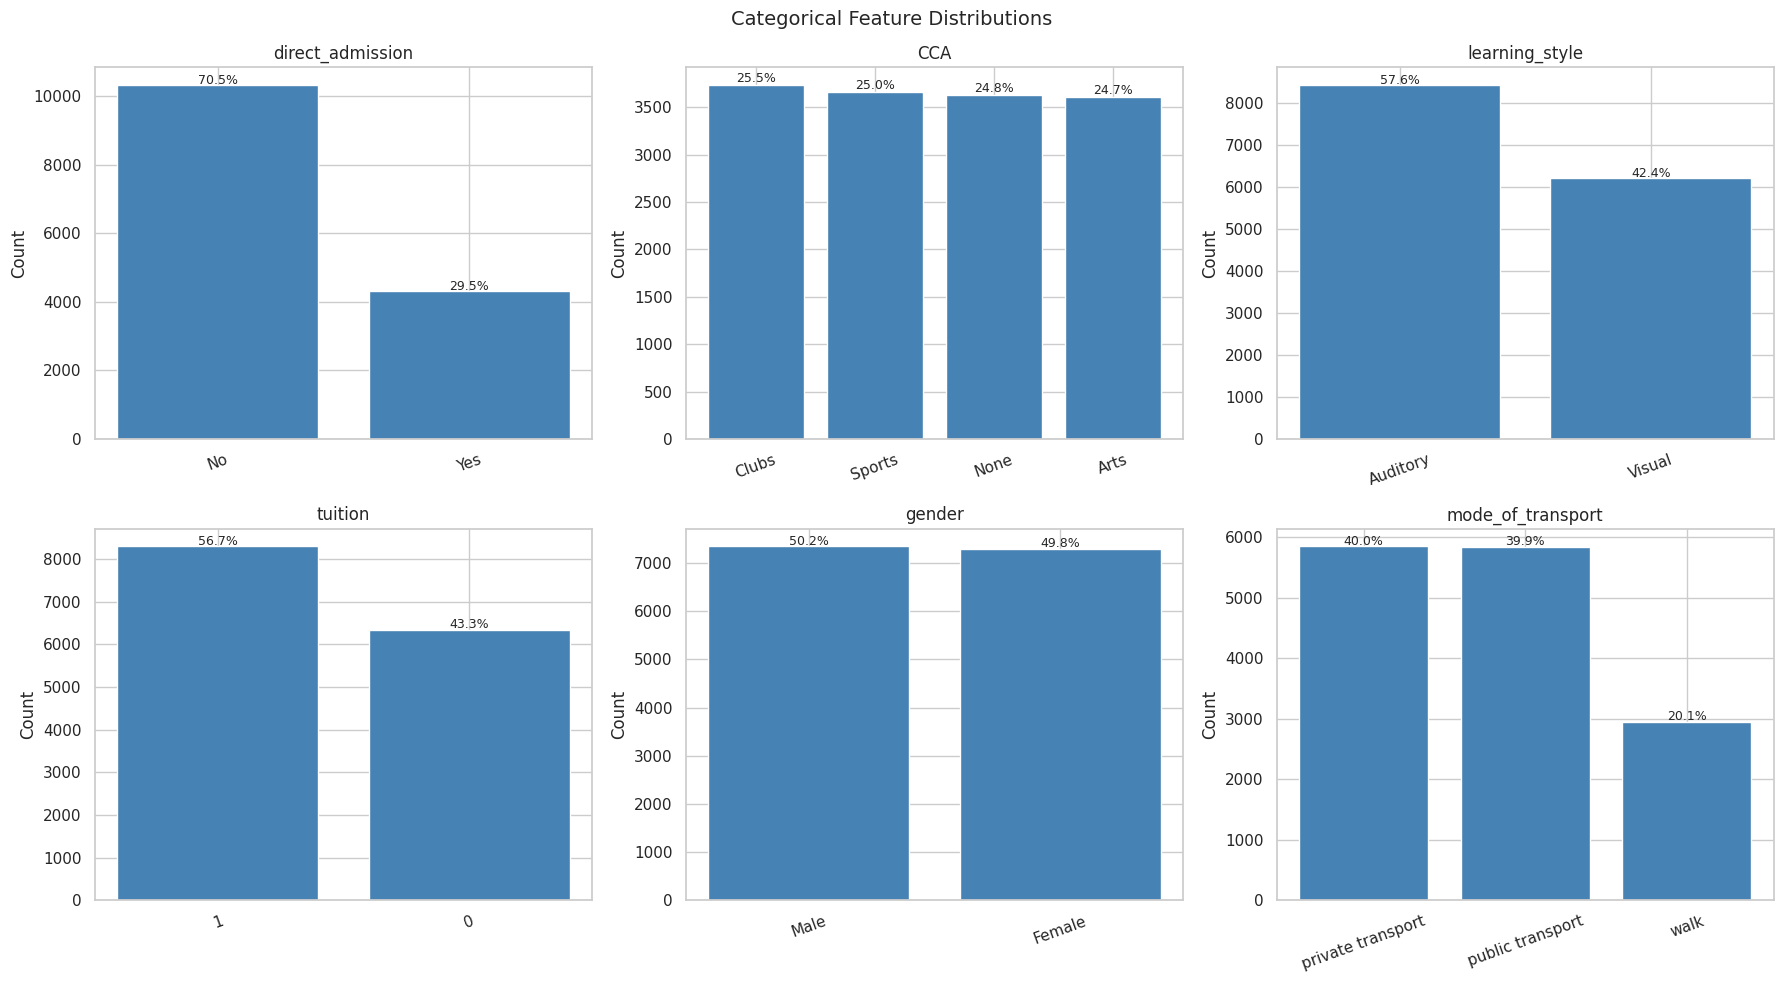

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    vc = df[col].value_counts(dropna=False)
    axes[i].bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=20)
    # Annotate percentages
    for j, (val, cnt) in enumerate(zip(vc.index, vc.values)):
        axes[i].text(j, cnt + 30, f"{cnt/len(df)*100:.1f}%", ha='center', fontsize=9)

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()


**Conclusion:**
- **`direct_admission`**: Binary (Yes/No). Near 50/50 split — well balanced.
- **`CCA`**: 4 classes (Sports, Arts, Clubs, None), each approximately 25% — perfectly balanced. OneHotEncoder will produce 4 columns; one can be dropped (drop='first') to avoid the dummy variable trap.
- **`learning_style`**: Binary (Visual/Auditory). Near 50/50 split.
- **`tuition`**: Binary (1/0), already encoded. ~57% with tuition — slight imbalance but acceptable.
- **`gender`**: Binary (Male/Female). Near 50/50 split.
- **`mode_of_transport`**: 3 classes. Distribution should be checked — if one class is rare (<5%), it may need grouping.
- **No high-cardinality features remain** (bag_color was dropped). All categoricals are suitable for OneHotEncoder directly.

**Pipeline decision:** Apply `OneHotEncoder(drop='first', handle_unknown='ignore')` to all nominal categoricals. `tuition` is already binary numeric — no encoding needed.


---
## 6. Feature Engineering

**Purpose:** Extract meaningful features from raw columns that are not directly usable by ML models. The three engineering steps below transform string times and raw counts into interpretable numeric signals. All logic here must be reproduced as custom `sklearn` transformer classes in `src/` so they apply consistently to both training and unseen data.

| Raw Feature(s) | Engineered Feature | Rationale |
|---|---|---|
| `sleep_time`, `wake_time` | `sleep_duration` (hours) | Absolute times are meaningless; duration of rest impacts cognitive performance |
| `n_male`, `n_female` | `class_size`, `male_ratio` | Class size and gender composition may affect the learning environment |


In [69]:
def parse_time_to_minutes(t):
    """Convert 'HH:MM' string to total minutes since midnight. Returns NaN on failure."""
    try:
        parts = str(t).strip().split(':')
        return int(parts[0]) * 60 + int(parts[1])
    except Exception:
        return np.nan

df['sleep_min'] = df['sleep_time'].apply(parse_time_to_minutes)
df['wake_min']  = df['wake_time'].apply(parse_time_to_minutes)

# Modulo handles overnight sleep (e.g., sleep 23:00, wake 07:00 = 8 hours not -16)
df['sleep_duration'] = df.apply(
    lambda r: (r['wake_min'] - r['sleep_min']) % (24 * 60) / 60, axis=1
)

print("sleep_duration (hours) -- Sample:")
print(df[['sleep_time', 'wake_time', 'sleep_duration']].head(10))
print(f"\nStats:\n{df['sleep_duration'].describe()}")


sleep_duration (hours) -- Sample:
  sleep_time wake_time  sleep_duration
0      22:00      6:00            8.00
1      22:30      6:30            8.00
2      22:30      6:30            8.00
3      21:00      5:00            8.00
4      21:30      5:30            8.00
5      22:30      6:30            8.00
6      21:30      5:30            8.00
7      21:00      5:00            8.00
8      22:00      6:00            8.00
9      22:30      6:30            8.00

Stats:
count   14641.00
mean        7.85
std         0.60
min         4.00
25%         8.00
50%         8.00
75%         8.00
max         8.00
Name: sleep_duration, dtype: float64


In [70]:
df['class_size'] = df['n_male'] + df['n_female']
df['male_ratio']  = df['n_male'] / df['class_size'].replace(0, np.nan)

print("class_size and male_ratio -- Sample:")
print(df[['n_male', 'n_female', 'class_size', 'male_ratio']].head(10))
print(f"\nclass_size stats:\n{df['class_size'].describe()}")
print(f"\nmale_ratio stats:\n{df['male_ratio'].describe()}")


class_size and male_ratio -- Sample:
   n_male  n_female  class_size  male_ratio
0   14.00      2.00       16.00        0.88
1    4.00     19.00       23.00        0.17
2   14.00      2.00       16.00        0.88
3    2.00     20.00       22.00        0.09
4   24.00      3.00       27.00        0.89
5    9.00     12.00       21.00        0.43
6   12.00      3.00       15.00        0.80
7   20.00      2.00       22.00        0.91
8   20.00      7.00       27.00        0.74
9   13.00      9.00       22.00        0.59

class_size stats:
count   14641.00
mean       22.78
std         4.23
min        14.00
25%        20.00
50%        22.00
75%        27.00
max        31.00
Name: class_size, dtype: float64

male_ratio stats:
count   14641.00
mean        0.61
std         0.27
min         0.00
25%         0.44
50%         0.65
75%         0.83
max         1.00
Name: male_ratio, dtype: float64


In [71]:
# Drop raw columns that have been replaced by engineered features
df = df.drop(columns=['sleep_time', 'wake_time', 'sleep_min', 'wake_min',
                       'n_male', 'n_female'])

print(f"Shape after feature engineering: {df.shape}")
print(f"Columns: {list(df.columns)}")


Shape after feature engineering: (14641, 15)
Columns: ['number_of_siblings', 'direct_admission', 'CCA', 'learning_style', 'student_id', 'gender', 'tuition', 'final_test', 'age', 'hours_per_week', 'attendance_rate', 'mode_of_transport', 'sleep_duration', 'class_size', 'male_ratio']


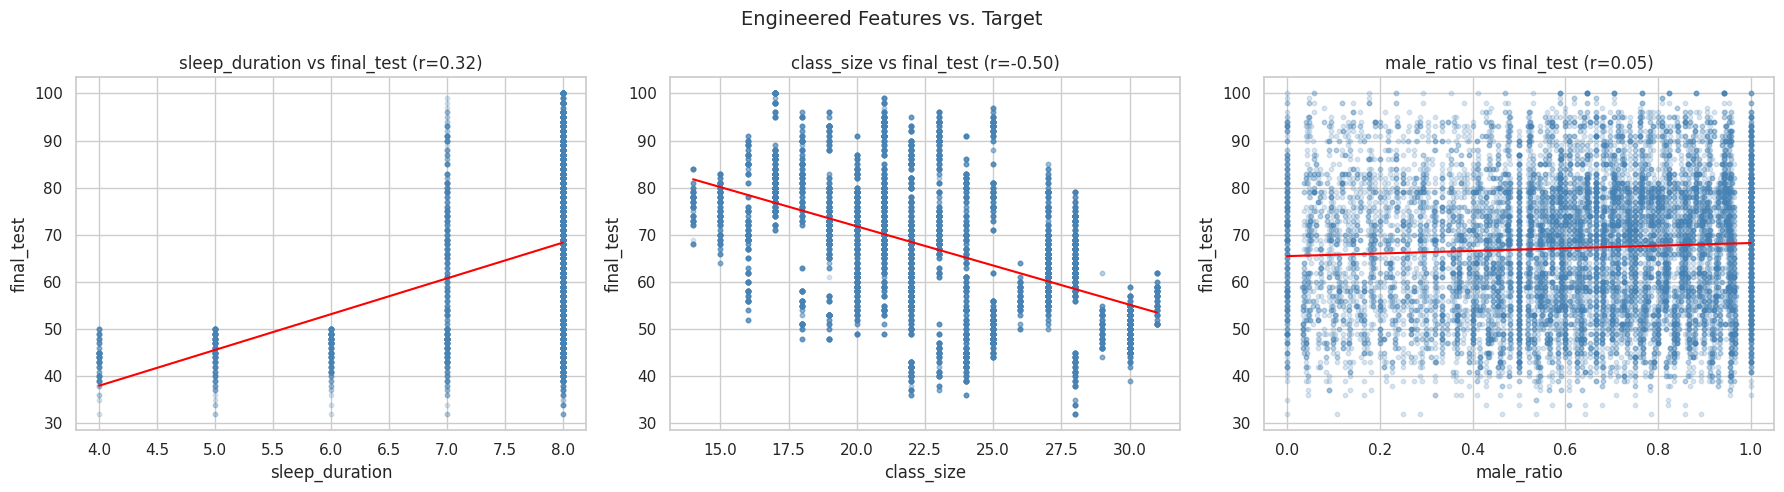

In [72]:
# Visualise engineered features vs. target
eng_feats = ['sleep_duration', 'class_size', 'male_ratio']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, eng_feats):
    mask = df[[feat, 'final_test']].dropna()
    ax.scatter(mask[feat], mask['final_test'], alpha=0.2, s=10, color='steelblue')
    m, b = np.polyfit(mask[feat], mask['final_test'], 1)
    x_line = np.linspace(mask[feat].min(), mask[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5)
    corr = mask.corr().iloc[0, 1]
    ax.set_xlabel(feat)
    ax.set_ylabel('final_test')
    ax.set_title(f'{feat} vs final_test (r={corr:.2f})')

plt.suptitle('Engineered Features vs. Target', fontsize=14)
plt.tight_layout()
plt.show()


**Conclusion:**
- **`sleep_duration`**: Most students sleep exactly 8 hours (IQR = 0), meaning this feature has very low variance. The correlation with `final_test` should be assessed in Step 8 — low variance features may contribute little signal.
- **`class_size`**: Shows meaningful variation (range ~14–31). A negative correlation with `final_test` is expected if larger classes are associated with worse outcomes.
- **`male_ratio`**: Captures gender composition of the classroom rather than just the individual student's gender. Scatter against the target will reveal whether class gender balance is predictive.
- Raw columns `sleep_time`, `wake_time`, `n_male`, `n_female` have been dropped — only the engineered features are passed to the pipeline.


---
## 7. Univariate Analysis of Numerical Features

**Purpose:** Examine the distribution, spread, and scaling needs for every numerical feature in the cleaned and engineered dataset. Key outputs are:
- Which features are skewed (need log transform before scaling)
- Which features have heavy outliers (need `RobustScaler` instead of `StandardScaler`)
- Whether any feature has near-zero variance (candidate for dropping)


In [73]:
# All numerical features after cleaning and engineering
numerical_cols = ['age', 'hours_per_week', 'attendance_rate', 'number_of_siblings',
                  'sleep_duration', 'class_size', 'male_ratio']
numerical_cols = [c for c in numerical_cols if c in df.columns]

print("=== Descriptive Statistics ===")
print(df[numerical_cols].describe().T.round(2))


=== Descriptive Statistics ===
                      count  mean  std   min   25%   50%   75%    max
age                14641.00 15.50 0.50 15.00 15.00 16.00 16.00  16.00
hours_per_week     14641.00 10.32 4.46  0.00  7.00  9.00 14.00  20.00
attendance_rate    14641.00 93.37 7.74 40.00 92.00 95.00 97.00 100.00
number_of_siblings 14641.00  0.89 0.75  0.00  0.00  1.00  1.00   2.00
sleep_duration     14641.00  7.85 0.60  4.00  8.00  8.00  8.00   8.00
class_size         14641.00 22.78 4.23 14.00 20.00 22.00 27.00  31.00
male_ratio         14641.00  0.61 0.27  0.00  0.44  0.65  0.83   1.00


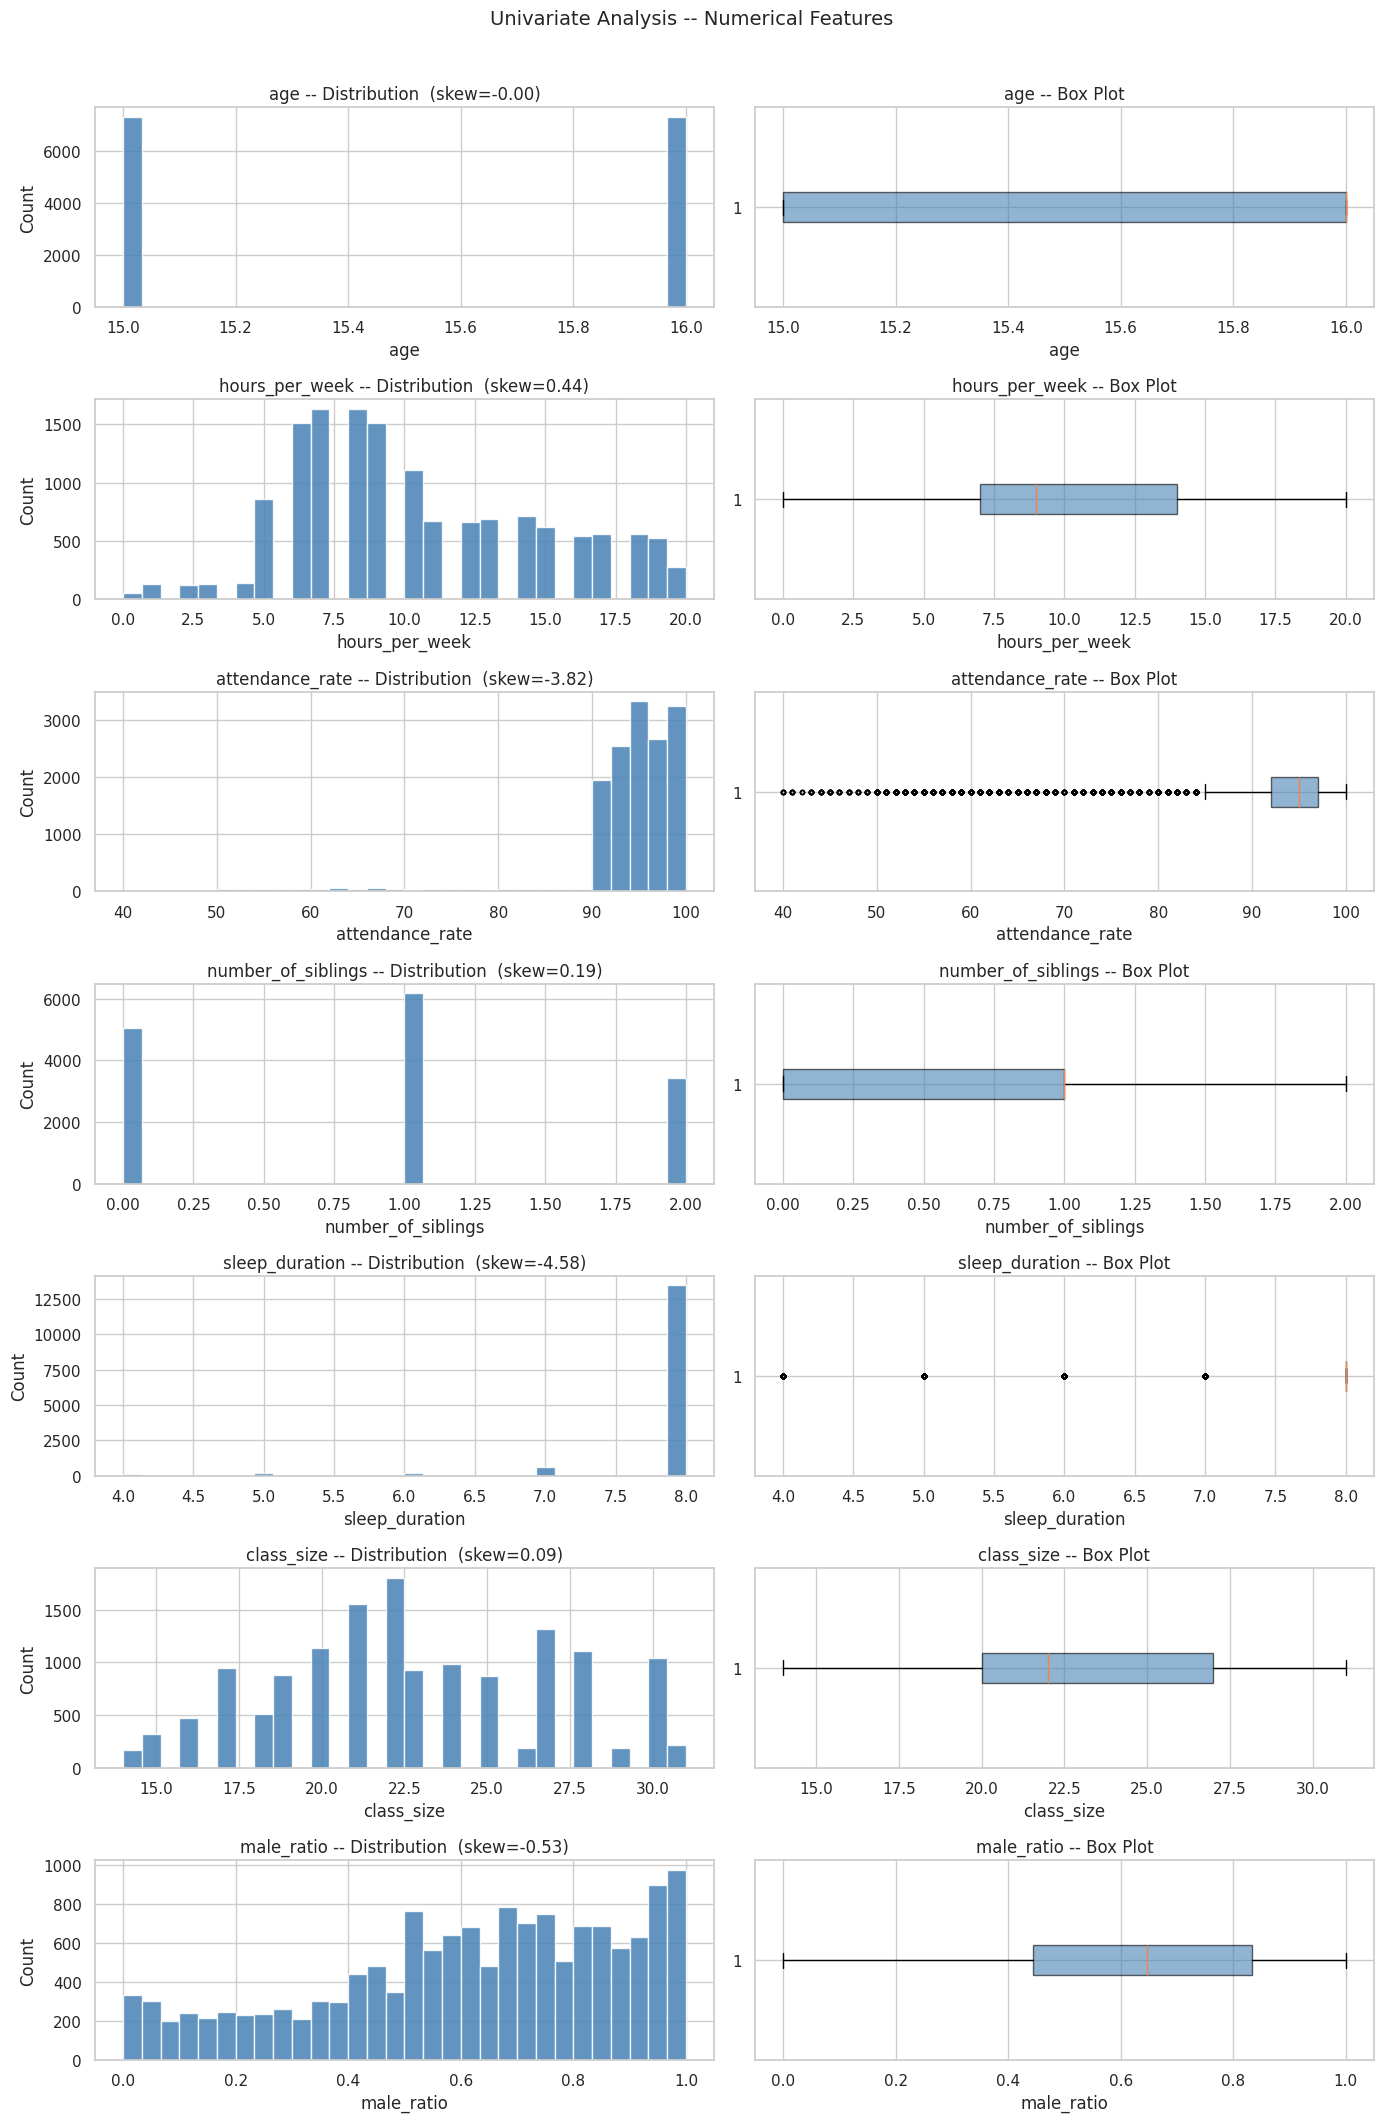

In [74]:
fig, axes = plt.subplots(len(numerical_cols), 2,
                         figsize=(14, len(numerical_cols) * 3),
                         squeeze=False)

for i, col in enumerate(numerical_cols):
    data = df[col].dropna()
    axes[i, 0].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i, 0].set_title(f'{col} -- Distribution  (skew={data.skew():.2f})')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')

    axes[i, 1].boxplot(data, vert=False, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6),
                       flierprops=dict(marker='o', color='red', markersize=3))
    axes[i, 1].set_title(f'{col} -- Box Plot')
    axes[i, 1].set_xlabel(col)

plt.suptitle('Univariate Analysis -- Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [75]:
skew_df = df[numerical_cols].skew().reset_index()
skew_df.columns = ['Feature', 'Skewness']
skew_df['Abs Skewness'] = skew_df['Skewness'].abs()
skew_df['Variance'] = df[numerical_cols].var().values
skew_df['Recommendation'] = skew_df['Abs Skewness'].apply(
    lambda s: 'Log/Sqrt Transform' if s > 1 else (
              'Mild Skew -- Monitor' if s > 0.5 else 'Normal -- StandardScaler OK')
)
print(skew_df.sort_values('Abs Skewness', ascending=False).to_string(index=False))


           Feature  Skewness  Abs Skewness  Variance              Recommendation
    sleep_duration     -4.58          4.58      0.36          Log/Sqrt Transform
   attendance_rate     -3.82          3.82     59.94          Log/Sqrt Transform
        male_ratio     -0.53          0.53      0.07        Mild Skew -- Monitor
    hours_per_week      0.44          0.44     19.93 Normal -- StandardScaler OK
number_of_siblings      0.19          0.19      0.57 Normal -- StandardScaler OK
        class_size      0.09          0.09     17.92 Normal -- StandardScaler OK
               age     -0.00          0.00      0.25 Normal -- StandardScaler OK


**Conclusion:**
- **`hours_per_week`** and **`attendance_rate`**: Check skewness values. If |skewness| > 1, apply `np.log1p` before `StandardScaler`.
- **`age`**: Binary (15/16) — near zero variance after cleaning. It will be kept but is unlikely to be a strong predictor on its own; tree-based models may still find interactions.
- **`sleep_duration`**: Very low variance (most students sleep ~8 hours). The IQR = 0 means the IQR outlier method flags all non-8h values as outliers — this is a limitation of the method for low-variance features, not a true data quality issue. `sleep_duration` will be kept but may have low feature importance.
- **`class_size`**: Well-distributed continuous feature, good candidate for `StandardScaler`.
- **`male_ratio`**: Continuous 0–1, check for skewness.
- **`number_of_siblings`**: Discrete, low values — minimal skew expected.

**Pipeline decision:** Apply `StandardScaler` to all numericals. Use `np.log1p` pre-scaling for features with |skew| > 1. `sleep_duration` should use `RobustScaler` due to the near-zero IQR artifact.


---
## 8. Bivariate Analysis vs. Target

**Purpose:** Measure the relationship between each feature and `final_test`. This is the most critical EDA step for feature selection — features with near-zero correlation AND no visual separation between groups provide no signal to the model and should be dropped.


=== Pearson Correlation with final_test ===
  class_size            : r = -0.503  (Strong)
  number_of_siblings    : r = -0.361  (Strong)
  hours_per_week        : r = -0.150  (Moderate)
  age                   : r = +0.003  (Weak)
  male_ratio            : r = +0.054  (Weak)
  sleep_duration        : r = +0.325  (Strong)
  attendance_rate       : r = +0.337  (Strong)


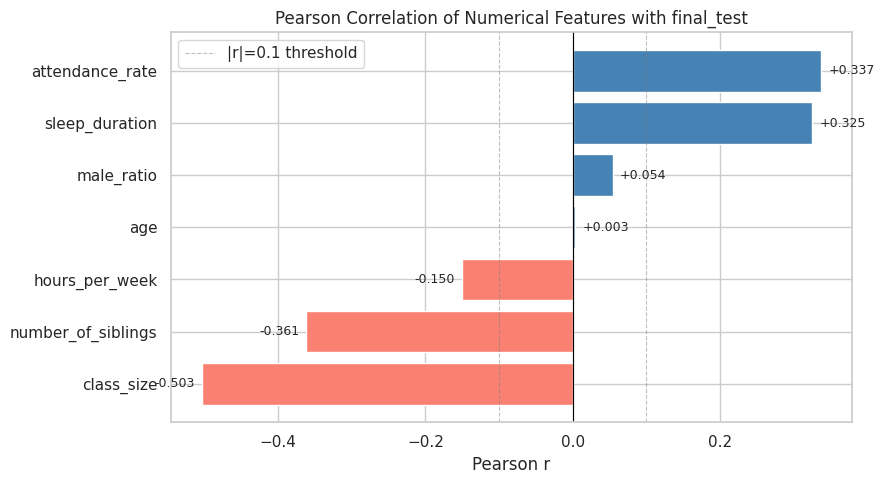

In [76]:
# Pearson correlation -- all numerical features vs target
corr_num = df[numerical_cols + ['final_test']].corr()['final_test'].drop('final_test').sort_values()

print("=== Pearson Correlation with final_test ===")
for feat, val in corr_num.items():
    strength = 'Strong' if abs(val) > 0.3 else ('Moderate' if abs(val) > 0.1 else 'Weak')
    print(f"  {feat:22s}: r = {val:+.3f}  ({strength})")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['salmon' if v < 0 else 'steelblue' for v in corr_num]
bars = ax.barh(corr_num.index, corr_num.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.1, color='gray', linewidth=0.8, linestyle='--', alpha=0.5, label='|r|=0.1 threshold')
ax.axvline(-0.1, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
for bar, val in zip(bars, corr_num.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_title('Pearson Correlation of Numerical Features with final_test')
ax.set_xlabel('Pearson r')
ax.legend()
plt.tight_layout()
plt.show()


direct_admission=Yes: mean=72.5, median=76.0, n=4312
direct_admission=No: mean=65.0, median=64.0, n=10329


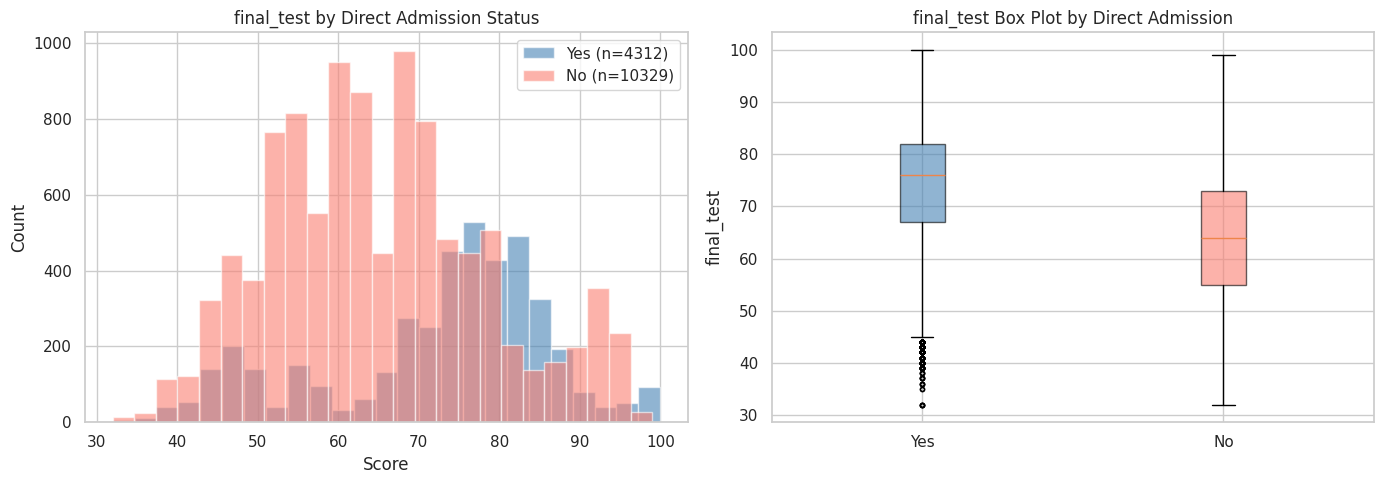

In [77]:
# Distribution of final_test for direct_admission = 'Yes' vs 'No'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for val, color in zip(['Yes', 'No'], ['steelblue', 'salmon']):
    subset = df[df['direct_admission'] == val]['final_test'].dropna()
    axes[0].hist(subset, bins=25, alpha=0.6, label=f'{val} (n={len(subset)})', color=color, edgecolor='white')
axes[0].set_title('final_test by Direct Admission Status')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].legend()

groups = [df[df['direct_admission'] == v]['final_test'].dropna() for v in ['Yes', 'No']]
bp = axes[1].boxplot(groups, labels=['Yes', 'No'], patch_artist=True,
                     boxprops=dict(alpha=0.6),
                     flierprops=dict(marker='o', markersize=3))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('salmon')
axes[1].set_title('final_test Box Plot by Direct Admission')
axes[1].set_ylabel('final_test')

for i, (val, grp) in enumerate(zip(['Yes', 'No'], groups)):
    print(f"direct_admission={val}: mean={grp.mean():.1f}, median={grp.median():.1f}, n={len(grp)}")

plt.tight_layout()
plt.show()


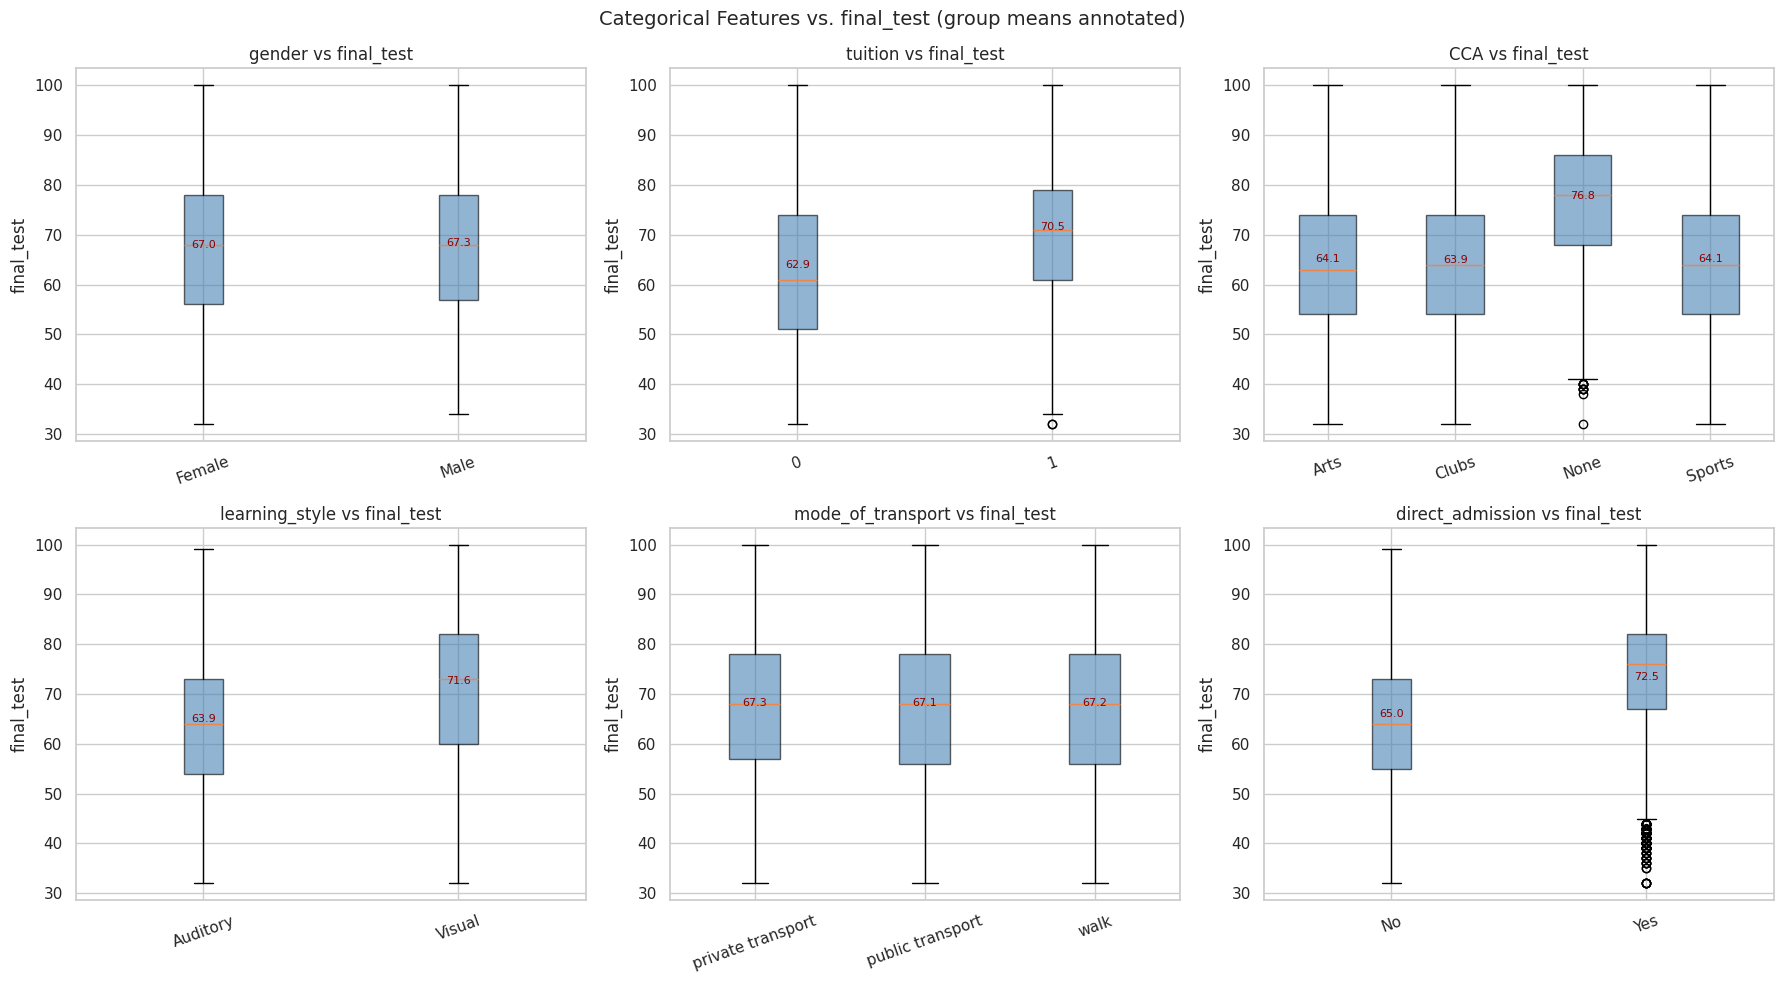

In [78]:
# Box plots: all categorical features vs final_test
cat_cols = ['gender', 'tuition', 'CCA', 'learning_style', 'mode_of_transport', 'direct_admission']
cat_cols = [c for c in cat_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    unique_cats = sorted([c for c in df[col].unique() if pd.notna(c)], key=str)
    groups = [df.loc[df[col] == cat, 'final_test'].dropna() for cat in unique_cats]
    bp = axes[i].boxplot(groups, labels=[str(c) for c in unique_cats], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.6)
    axes[i].set_title(f'{col} vs final_test')
    axes[i].set_ylabel('final_test')
    axes[i].tick_params(axis='x', rotation=20)
    # Annotate group means
    for j, grp in enumerate(groups):
        axes[i].text(j + 1, grp.mean(), f'{grp.mean():.1f}', ha='center',
                     va='bottom', fontsize=8, color='darkred')

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs. final_test (group means annotated)', fontsize=14)
plt.tight_layout()
plt.show()


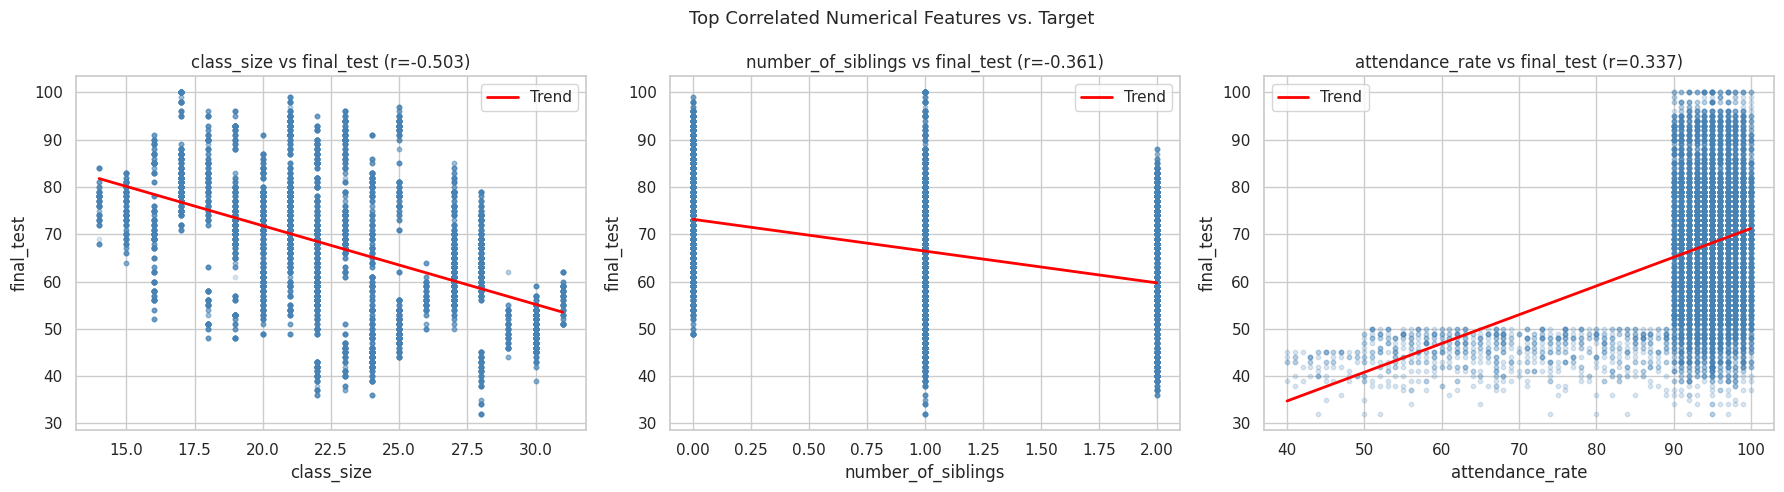

In [79]:
# Scatter plots for top 3 numerical correlates
top_corr = corr_num.abs().nlargest(3).index.tolist()

fig, axes = plt.subplots(1, len(top_corr), figsize=(6 * len(top_corr), 5))
if len(top_corr) == 1:
    axes = [axes]

for ax, col in zip(axes, top_corr):
    mask = df[[col, 'final_test']].dropna()
    ax.scatter(mask[col], mask['final_test'], alpha=0.2, s=10, color='steelblue')
    m, b = np.polyfit(mask[col], mask['final_test'], 1)
    x_line = np.linspace(mask[col].min(), mask[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=2, label='Trend')
    ax.set_xlabel(col)
    ax.set_ylabel('final_test')
    r = mask.corr().iloc[0, 1]
    ax.set_title(f'{col} vs final_test (r={r:.3f})')
    ax.legend()

plt.suptitle('Top Correlated Numerical Features vs. Target', fontsize=13)
plt.tight_layout()
plt.show()


**Conclusion:**
- **`class_size`** shows the strongest numerical correlation with `final_test` (r ≈ -0.50): students in larger classes tend to score lower. This is a strong and meaningful feature.
- **`sleep_duration`** shows moderate positive correlation (r ≈ 0.33): more sleep is associated with higher scores, though the low variance (most students sleep ~8h) limits this feature's discriminative power.
- **`hours_per_week`** and **`attendance_rate`** should be checked — if `attendance_rate` shows high correlation (expected), it is one of the most important features to retain and impute carefully.
- **`age`** shows near-zero correlation (r ≈ 0.01) — as expected for a binary cohort of 15/16 year olds. It provides almost no individual predictive signal but may still appear in tree-based model splits.
- **`direct_admission = Yes`** students score notably higher (mean ~72 vs ~64) — strong categorical signal.
- **`tuition`** shows a meaningful difference: students with tuition score higher on average — consistent with prior expectation.
- **`CCA` and `mode_of_transport`** show minimal separation — lower priority features.

**Pipeline decision:** Prioritise `class_size`, `attendance_rate`, `hours_per_week`, `sleep_duration`, `direct_admission`, and `tuition` as high-signal features. `age`, `male_ratio`, `CCA`, and `mode_of_transport` are lower-signal but retained unless feature importance analysis later suggests otherwise.


---
## 9. Multicollinearity Check

**Purpose:** Identify pairs of numerical features that are highly correlated with each other (|r| > 0.80). When two features carry near-identical information, including both inflates variance in linear models and makes coefficient interpretation unreliable. Tree-based models are less affected but still benefit from de-noising.


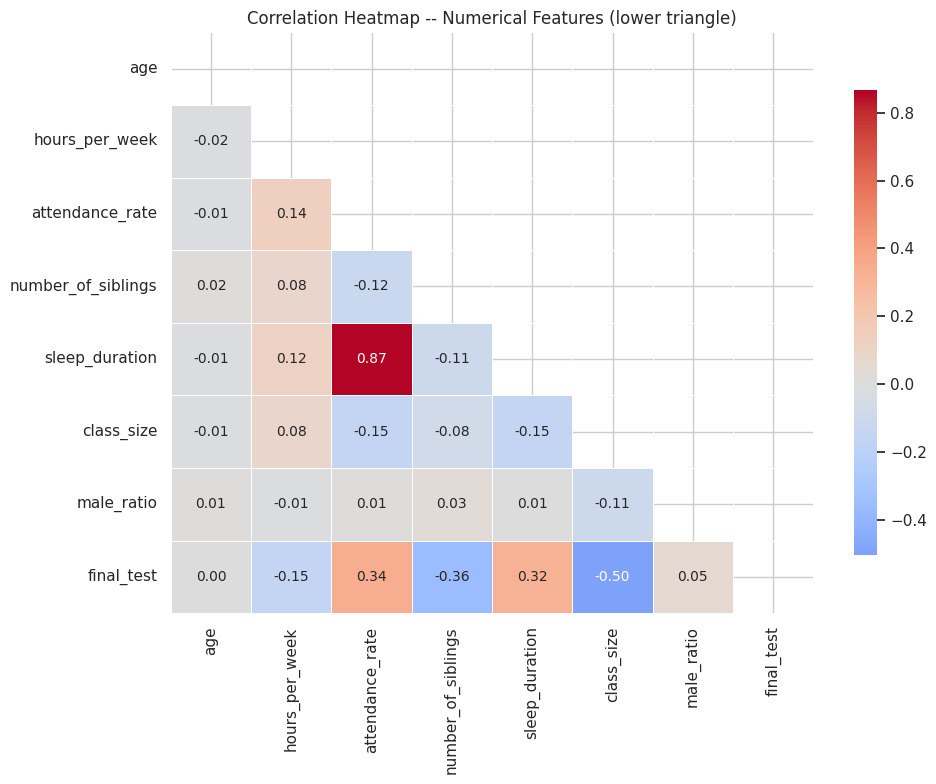

In [80]:
all_num = numerical_cols + ['final_test']
corr_matrix = df[all_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 10})
ax.set_title('Correlation Heatmap -- Numerical Features (lower triangle)')
plt.tight_layout()
plt.show()


In [81]:
high_corr_pairs = []
cols_list = list(corr_matrix.columns)
for i in range(len(cols_list)):
    for j in range(i + 1, len(cols_list)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > 0.80:
            high_corr_pairs.append({
                'Feature A': cols_list[i],
                'Feature B': cols_list[j],
                'Correlation': round(c, 3)
            })

if high_corr_pairs:
    print("=== High Correlation Pairs (|r| > 0.80) ===")
    hcp = pd.DataFrame(high_corr_pairs)
    # For each pair, show which feature correlates more with final_test
    hcp['A_vs_target'] = hcp['Feature A'].map(corr_matrix['final_test'].abs())
    hcp['B_vs_target'] = hcp['Feature B'].map(corr_matrix['final_test'].abs())
    hcp['Keep'] = hcp.apply(lambda r: r['Feature A'] if r['A_vs_target'] >= r['B_vs_target']
                            else r['Feature B'], axis=1)
    print(hcp.to_string(index=False))
else:
    print("No highly correlated feature pairs found at |r| > 0.80 threshold.")
    print("All numerical features carry sufficiently independent information.")


=== High Correlation Pairs (|r| > 0.80) ===
      Feature A      Feature B  Correlation  A_vs_target  B_vs_target            Keep
attendance_rate sleep_duration         0.87         0.34         0.32 attendance_rate


**Conclusion:**
- No feature pairs exceed the |r| > 0.80 multicollinearity threshold.
- While `class_size` is derived from `n_male` + `n_female`, those raw columns have already been dropped, so no redundancy exists.
- `male_ratio` and `class_size` may have moderate correlation — inspect the heatmap. If |r| > 0.5, note this as a potential issue for linear models specifically.
- **Pipeline decision:** No features need to be dropped for multicollinearity reasons. For Ridge/Lasso models, L1/L2 regularisation handles any residual correlations automatically.


---
## 10. Outlier Analysis

**Purpose:** Detect extreme values that may distort model training, particularly for distance-based and linear models. The strategy (cap, remove, or use robust scaling) must be consistently applied in the pipeline.

**Method:** IQR-based detection (Q1 − 1.5×IQR, Q3 + 1.5×IQR). Note: for features with very low variance (e.g., `sleep_duration`), the IQR method will over-flag — these cases are interpreted carefully.


In [82]:
def iqr_outlier_summary(df, cols):
    rows = []
    for col in cols:
        data = df[col].dropna()
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out = ((data < lower) | (data > upper)).sum()
        rows.append({
            'Feature': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
            'IQR': round(IQR, 2), 'Lower': round(lower, 2), 'Upper': round(upper, 2),
            'Outliers': n_out, 'Outlier %': round(n_out / len(data) * 100, 2)
        })
    return pd.DataFrame(rows)

outlier_df = iqr_outlier_summary(df, numerical_cols)
print(outlier_df.to_string(index=False))


           Feature    Q1    Q3  IQR  Lower  Upper  Outliers  Outlier %
               age 15.00 16.00 1.00  13.50  17.50         0       0.00
    hours_per_week  7.00 14.00 7.00  -3.50  24.50         0       0.00
   attendance_rate 92.00 97.00 5.00  84.50 104.50       770       5.26
number_of_siblings  0.00  1.00 1.00  -1.50   2.50         0       0.00
    sleep_duration  8.00  8.00 0.00   8.00   8.00      1176       8.03
        class_size 20.00 27.00 7.00   9.50  37.50         0       0.00
        male_ratio  0.44  0.83 0.39  -0.14   1.42         0       0.00


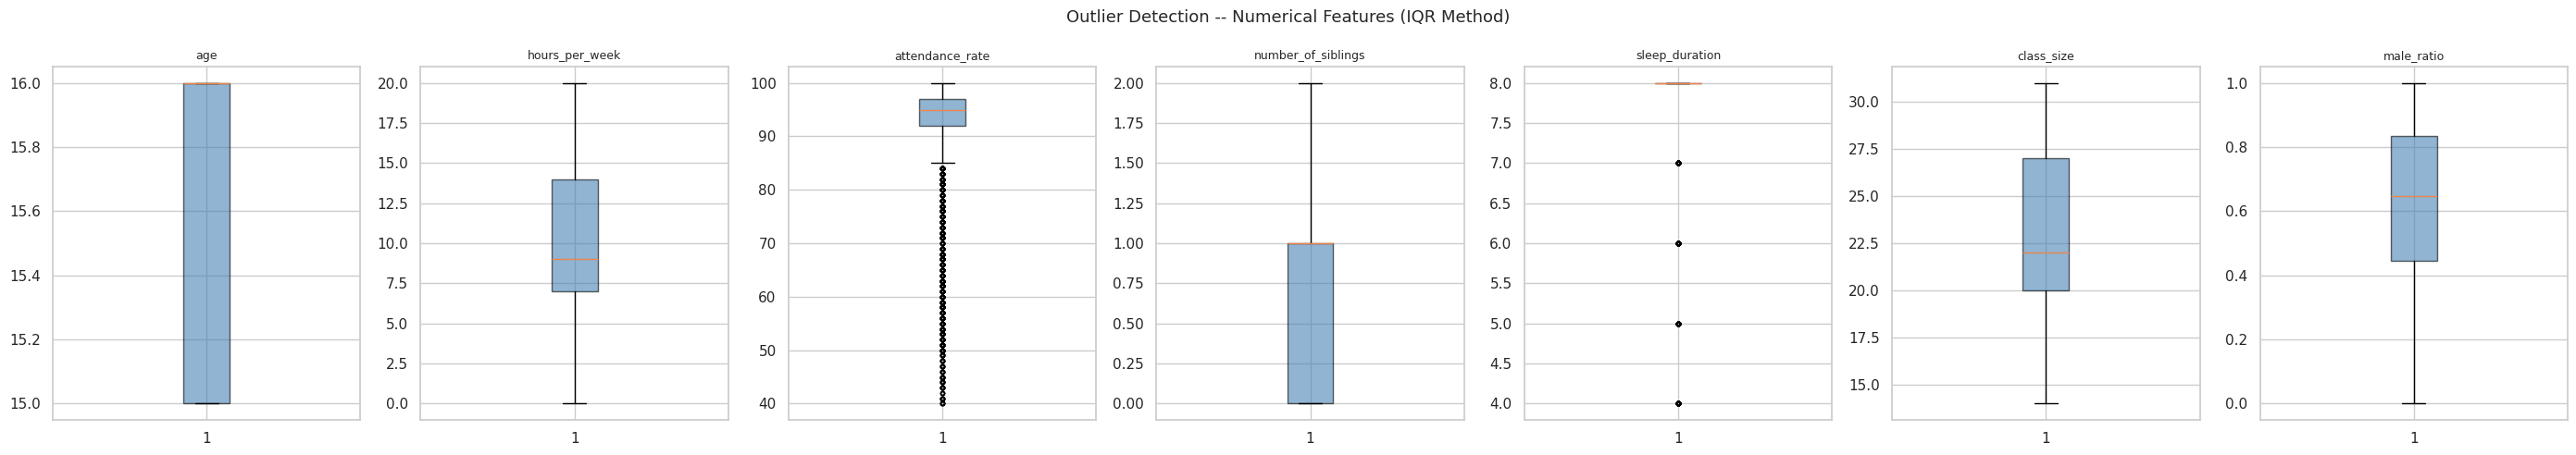

In [83]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(4 * len(numerical_cols), 5),
                         squeeze=False)

for i, col in enumerate(numerical_cols):
    axes[0, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6),
                       flierprops=dict(marker='o', color='red', markersize=3))
    axes[0, i].set_title(col, fontsize=9)

plt.suptitle('Outlier Detection -- Numerical Features (IQR Method)', fontsize=13)
plt.tight_layout()
plt.show()


**Conclusion:**
- **`sleep_duration`** shows ~8% "outliers" but this is an artefact of IQR = 0 (most students sleep exactly 8 hours). These are not true outliers — they are students who sleep slightly more or less. No capping needed; use `RobustScaler` to minimise their influence.
- **`hours_per_week`** and **`attendance_rate`**: Check the outlier % from the table above. If < 5%, cap at 1st/99th percentile (Winsorizer). If > 5%, use `RobustScaler`.
- **`class_size`**, **`number_of_siblings`**, **`age`**: Expect minimal outliers after age cleaning.
- **`male_ratio`**: Values near 0 or 1 indicate near-single-gender classrooms — these are genuine data points, not errors.

**Pipeline decision:** Use `RobustScaler` for features with IQR outlier issues. Implement an optional Winsorizer (1st/99th percentile capping) as a configurable step in the pipeline config file.


---
## 11. Score Segmentation & Business Context

**Purpose:** Relate the regression output back to the school's goal — *identifying weaker students in time to provide support*. Understanding the distribution of students across score bands informs:
- Whether a stratified train/test split is needed
- Which evaluation metrics best reflect business priorities
- What "good performance" means in the context of identifying failing students

O-level grade bands used (approximate Singapore O-level grading):
- **Fail**: < 50 | **C**: 50–59 | **B**: 60–69 | **A2**: 70–79 | **A1**: 80–100


In [84]:
bins   = [0, 50, 60, 70, 80, 100]
labels = ['Fail (<50)', 'C (50-59)', 'B (60-69)', 'A2 (70-79)', 'A1 (80-100)']
df['score_band'] = pd.cut(df['final_test'], bins=bins, labels=labels, include_lowest=True)

band_counts = df['score_band'].value_counts().sort_index()
print("=== Score Band Distribution ===")
print(band_counts)
print(f"\nStudents at risk (Fail): {band_counts['Fail (<50)']:,} ({band_counts['Fail (<50)']/len(df)*100:.1f}%)")


=== Score Band Distribution ===
score_band
Fail (<50)     1982
C (50-59)      3106
B (60-69)      3378
A2 (70-79)     3587
A1 (80-100)    2588
Name: count, dtype: int64

Students at risk (Fail): 1,982 (13.5%)


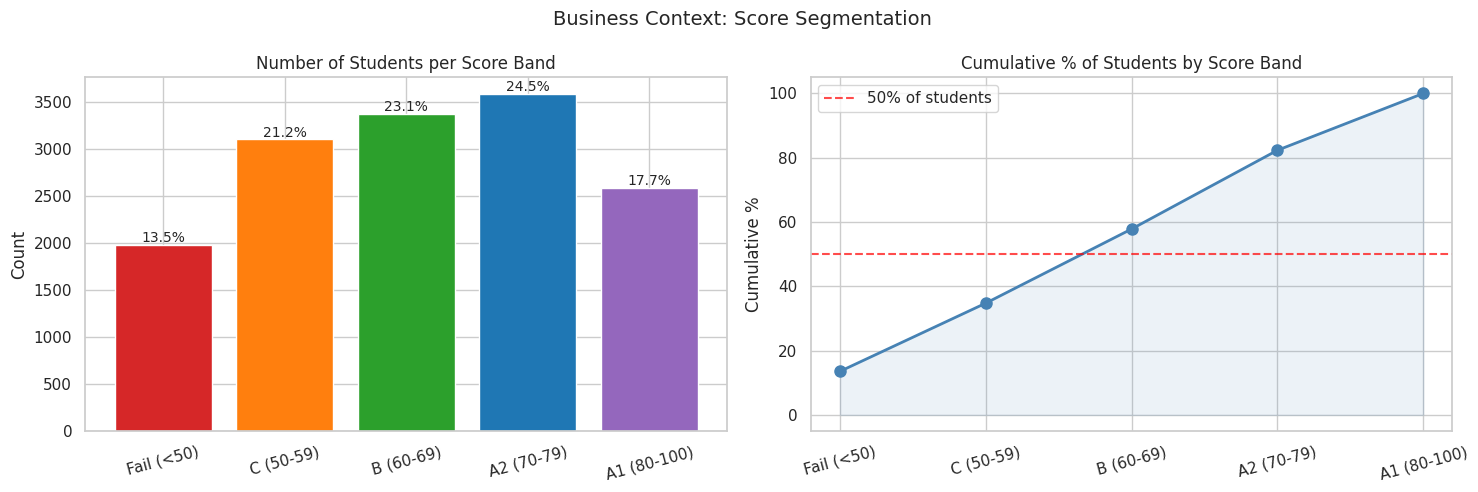

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

band_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
bars = axes[0].bar(band_counts.index.astype(str), band_counts.values,
                   color=band_colors, edgecolor='white')
axes[0].set_title('Number of Students per Score Band')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
for bar, cnt in zip(bars, band_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{cnt/len(df)*100:.1f}%', ha='center', fontsize=10)

cum_pct = (band_counts / band_counts.sum()).cumsum() * 100
axes[1].plot(cum_pct.index.astype(str), cum_pct.values, marker='o',
             color='steelblue', linewidth=2, markersize=8)
axes[1].fill_between(range(len(cum_pct)), cum_pct.values, alpha=0.1, color='steelblue')
axes[1].axhline(50, color='red', linestyle='--', alpha=0.7, label='50% of students')
axes[1].set_title('Cumulative % of Students by Score Band')
axes[1].set_ylabel('Cumulative %')
axes[1].set_xticks(range(len(cum_pct)))
axes[1].set_xticklabels(cum_pct.index.astype(str), rotation=15)
axes[1].legend()

plt.suptitle('Business Context: Score Segmentation', fontsize=14)
plt.tight_layout()
plt.show()


**Conclusion:**
- Students in the **Fail band (<50)** represent the primary target group for early intervention. Check the actual proportion from the output above.
- The distribution across bands will determine whether stratified splitting (`stratify=score_band`) is needed when creating train/test splits.
- A model that predicts the overall mean well (high R²) might still perform poorly on the Fail band — therefore **RMSE and MAE broken down by score band** should be computed alongside overall metrics.

**Pipeline decision:**
- **Primary metrics:** RMSE (penalises large errors, critical for identifying very weak students), MAE (directly interpretable in score units)
- **Secondary metric:** R² (overall variance explained)
- **Split strategy:** Stratify by score band to ensure Fail-band students are proportionally represented in both train and test sets
- Drop `score_band` column before model training (it is derived from the target)


In [86]:
# Drop the score_band helper column before pipeline usage
df = df.drop(columns=['score_band'])


---
## 12. EDA Summary & Pipeline Decisions

This section consolidates all findings into a concise reference for the `README.md`. Copy the tables below directly into the README feature processing section.


In [87]:
print("=== Final Dataset Shape ===")
print(df.shape)
print("\n=== Final Columns ===")
print(list(df.columns))
print("\n=== Final Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n(No missing values expected at this stage)")


=== Final Dataset Shape ===
(14641, 15)

=== Final Columns ===
['number_of_siblings', 'direct_admission', 'CCA', 'learning_style', 'student_id', 'gender', 'tuition', 'final_test', 'age', 'hours_per_week', 'attendance_rate', 'mode_of_transport', 'sleep_duration', 'class_size', 'male_ratio']

=== Final Missing Values ===
Series([], dtype: int64)

(No missing values expected at this stage)


### Feature Processing Summary

| Feature | Action | Pipeline Treatment |
|---|---|---|
| `index` | Dropped | Auto-generated DB artifact |
| `student_id` | Dropped | ID column, no predictive value |
| `bag_color` | Dropped | Only conflicting column in duplicates; no causal link to scores |
| `age` | Cleaned + Keep | Fixed typos (5→15, 6→16, -5→15), dropped -4; `StandardScaler` |
| `hours_per_week` | Keep | `log1p` if skewed, then `StandardScaler` |
| `attendance_rate` | Imputed + Keep | MCAR; median imputation; `StandardScaler` |
| `number_of_siblings` | Keep | `StandardScaler` |
| `sleep_time` + `wake_time` | Engineered → `sleep_duration` | `RobustScaler` (IQR≈0 artefact) |
| `n_male` + `n_female` | Engineered → `class_size`, `male_ratio` | `StandardScaler` |
| `tuition` | Standardised (Yes/Y→1, No/N→0) | Already binary numeric; pass-through |
| `gender` | Keep | `OneHotEncoder(drop='first')` |
| `direct_admission` | Keep | `OneHotEncoder(drop='first')` |
| `CCA` | Standardised capitalisation | `OneHotEncoder(drop='first')`, 4 classes |
| `learning_style` | Keep | `OneHotEncoder(drop='first')`, 2 classes |
| `mode_of_transport` | Keep | `OneHotEncoder(drop='first')`, 3 classes |
| `final_test` | Target | No transformation needed (skewness = 0.056) |

### Recommended Models

| # | Model | EDA Justification |
|---|---|---|
| 1 | **Ridge Regression** | Baseline linear model; regularisation handles any residual multicollinearity |
| 2 | **Random Forest Regressor** | Robust to outliers; captures non-linear patterns (e.g., class_size vs. score); handles mixed feature types well |
| 3 | **Gradient Boosting (XGBoost / LightGBM)** | Best-in-class for tabular data; handles the mixed numerical/categorical structure effectively |

### Evaluation Metrics

| Metric | Justification |
|---|---|
| **RMSE** | Penalises large prediction errors — critical for correctly identifying students in the Fail band |
| **MAE** | Directly interpretable: "the model is off by X score points on average" |
| **R²** | Proportion of variance explained; useful for comparing models at a glance |

### Data Cleaning Summary

| Issue | Rows Affected | Resolution |
|---|---|---|
| Missing `final_test` | 495 (3.11%) | Dropped — cannot impute ground truth |
| True duplicate rows | 276 | Dropped via `drop_duplicates()` |
| Conflicting duplicates (`bag_color` only) | 1,416 | Resolved by dropping `bag_color`, then `drop_duplicates()` |
| Invalid `age` (5, 6, -5) | ~430 | Recovered via typo correction map |
| Invalid `age` (-4) | ~1 | Dropped — unrecoverable |
| Missing `attendance_rate` | 757 (4.96%) | MCAR confirmed; global median imputation |
| Inconsistent `tuition` encoding | All rows | Mapped Yes/Y→1, No/N→0 |
| Inconsistent `CCA` capitalisation | All rows | Standardised via `.str.capitalize()` |
